In [41]:
import numpy as np
import pandas as pd
from scipy import sparse

import torch
from torch_geometric.data import Data


# ======================
# Load data
# ======================

X = np.load(
    "GCN_features.npy"
)

A = sparse.load_npz(
    "GCN_adjacency.npz"
)

metadata = pd.read_csv(
    "GCN_metadata.csv",
    index_col=0
)


print(X.shape)
print(A.shape)
print(metadata.shape)

(74088, 3000)
(74088, 74088)
(74088, 5)


In [28]:
labels = metadata["label"].values

y = torch.tensor(
    labels,
    dtype=torch.long
)

In [42]:
from sklearn.model_selection import train_test_split


# 有標籤的位置
label_idx = np.where(labels != -1)[0]


# train / validation
train_idx, val_idx = train_test_split(
    label_idx,
    test_size=0.2,
    stratify=labels[label_idx],
    random_state=42
)


train_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

val_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)


train_mask[train_idx] = True
val_mask[val_idx] = True


print("Train:", train_mask.sum())
print("Validation:", val_mask.sum())
print("Unknown:", (labels==-1).sum())

Train: tensor(19034)
Validation: tensor(4759)
Unknown: 50295


In [43]:
edge_index = torch.tensor(
    np.vstack(A.nonzero()),
    dtype=torch.long
)


print(edge_index.shape)

torch.Size([2, 1614610])


In [44]:
data = Data(
    x=torch.tensor(
        X,
        dtype=torch.float
    ),

    edge_index=edge_index,

    y=y,

    train_mask=train_mask,

    val_mask=val_mask
)

print(data)

Data(x=[74088, 3000], edge_index=[2, 1614610], y=[74088], train_mask=[74088], val_mask=[74088])


In [45]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = GCNConv(
            3000,
            64
        )

        self.conv2 = GCNConv(
            64,
            2
        )


    def forward(self, x, edge_index):

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.5,
            training=self.training
        )


        x = self.conv2(
            x,
            edge_index
        )

        return x

In [46]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


data = data.to(device)

model = GCN().to(device)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)


loss_fn = torch.nn.CrossEntropyLoss()

print("以下為訓練過程:")

for epoch in range(100):

    model.train()

    optimizer.zero_grad()


    out = model(
        data.x,
        data.edge_index
    )


    loss = loss_fn(
        out[data.train_mask],
        data.y[data.train_mask]
    )


    loss.backward()

    optimizer.step()



    # validation

    model.eval()

    with torch.no_grad():

        val_out = model(
            data.x,
            data.edge_index
        )

        pred = val_out.argmax(dim=1)

        correct = (
            pred[data.val_mask]
            ==
            data.y[data.val_mask]
        ).sum()

        acc = correct / data.val_mask.sum()


    if epoch % 10 == 0:

        print(
            epoch,
            "Loss:",
            loss.item(),
            "Val Acc:",
            acc.item()
        )


以下為訓練過程:
0 Loss: 0.8385828733444214 Val Acc: 0.8659382462501526
10 Loss: 0.1287650465965271 Val Acc: 0.9745745062828064
20 Loss: 0.15058456361293793 Val Acc: 0.9884429574012756
30 Loss: 0.06109697371721268 Val Acc: 0.9905442595481873
40 Loss: 0.03910904377698898 Val Acc: 0.9932758808135986
50 Loss: 0.021349024027585983 Val Acc: 0.9955872893333435
60 Loss: 0.021731354296207428 Val Acc: 0.996217668056488
70 Loss: 0.013968676328659058 Val Acc: 0.9955872893333435
80 Loss: 0.011120173148810863 Val Acc: 0.9957974553108215
90 Loss: 0.01051404234021902 Val Acc: 0.9966379404067993


In [47]:
from sklearn.metrics import confusion_matrix, classification_report


model.eval()

with torch.no_grad():

    out = model(
        data.x,
        data.edge_index
    )

    pred = out.argmax(dim=1) # 選擇模型輸出最高的類別

    # 感染機率 (class 1)
    prob = torch.softmax(
        out,
        dim=1
    )[:,1]



y_true = (
    data.y[data.val_mask]
    .cpu()
    .numpy()
)

y_pred = (
    pred[data.val_mask]
    .cpu()
    .numpy()
)

y_prob = (
    prob[data.val_mask]
    .cpu()
    .numpy()
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_true,
        y_pred
    )
)

print("")
print("Classification report:")
print(
    classification_report(
        y_true,
        y_pred
    )
)

Confusion matrix:
[[4413    3]
 [  14  329]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4416
           1       0.99      0.96      0.97       343

    accuracy                           1.00      4759
   macro avg       0.99      0.98      0.99      4759
weighted avg       1.00      1.00      1.00      4759



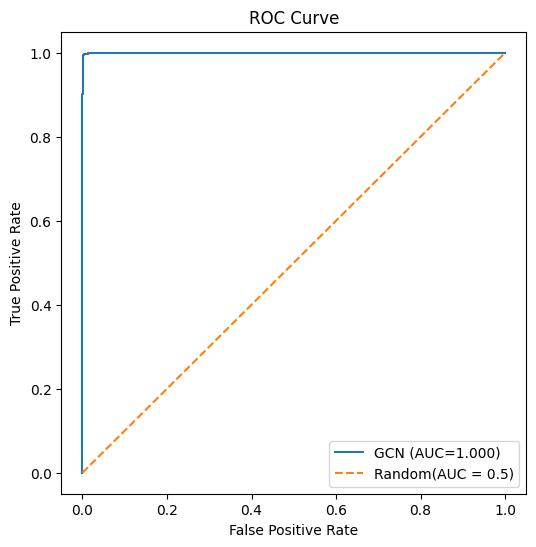

In [48]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


# 計算 ROC curve
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob
)


# 計算 AUC
auc = roc_auc_score(
    y_true,
    y_prob
)


plt.figure(figsize=(6,6))


plt.plot(
    fpr,
    tpr,
    label=f"GCN (AUC={auc:.3f})"
)


# random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random(AUC = 0.5)"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve"
)


plt.legend()

plt.show()

In [49]:
print(
    "ROC-AUC:",
    round(auc,4)
)

ROC-AUC: 0.9999


In [50]:
from sklearn.metrics import average_precision_score


pr_auc = average_precision_score(
    y_true,
    y_prob
)


print(
    "PR-AUC:",
    round(pr_auc,4)
)

PR-AUC: 0.9986
